In [1]:
import pandas as pd

df = pd.read_csv('..\data\mart_product_returns.csv')

In [2]:
df.head()

,product_id,product_name,category,segment,size,color,list_price,cogs,orders_count,total_units_sold,...,negative_reviews,stock_on_hand,days_of_supply,fill_rate,sell_through_rate,stockout_flag,overstock_flag,reorder_flag,latest_snapshot_date,product_risk_tier
0,689,SaigonFlex UC-54,Streetwear,Everyday,M,yellow,4162.627715,3842.937906,1910,8693,...,47,526,7890.0,1.0000,0.0038,False,True,False,2020-08-31,low_risk
1,993,HanoiStreet UC-56,Streetwear,Everyday,M,blue,4262.353834,3732.117017,5075,22604,...,95,1394,8364.0,1.0000,0.0036,False,True,False,2022-12-31,low_risk
2,1230,MekongFit UC-32,Streetwear,Everyday,L,red,5786.595352,3670.437432,504,2239,...,10,149,4470.0,0.9667,0.0067,True,True,False,2016-11-30,low_risk
3,432,SaigonFlex UM-37,Streetwear,Balanced,S,orange,11109.203180,10553.743021,1726,7910,...,43,430,12900.0,1.0000,0.0023,False,True,False,2017-08-31,low_risk
4,981,HanoiStreet UC-44,Streetwear,Everyday,M,black,2032.929931,1931.283435,4086,18198,...,122,1110,3700.0,0.9667,0.0080,True,True,False,2022-12-31,low_risk


# Descriptive

## 1, Mỗi category đang tạo ra bao nhiêu doanh thu? Phần bị khấu trừ lớn không?

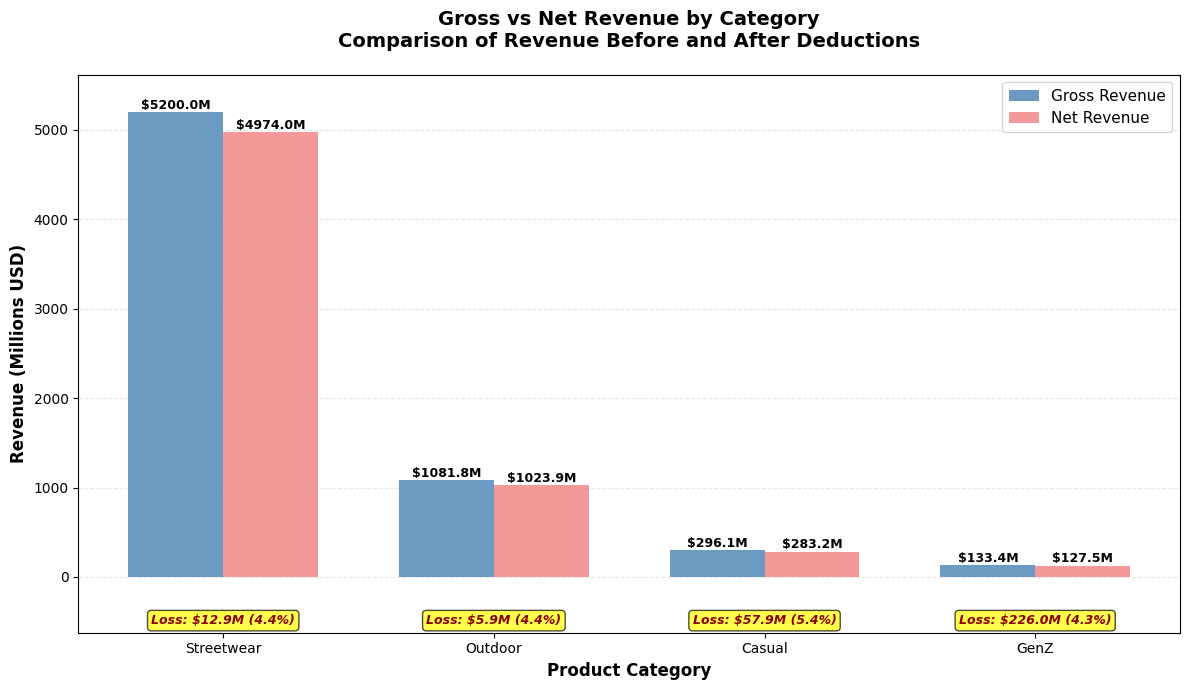


REVENUE ANALYSIS BY CATEGORY
Category        Gross Rev (M)   Net Rev (M)     Deduction (M)   Deduction % 
--------------------------------------------------------------------------------
Streetwear      $5200.0         $4974.0         $226.0          4.3        %
Outdoor         $1081.8         $1023.9         $57.9           5.4        %
Casual          $296.1          $283.2          $12.9           4.4        %
GenZ            $133.4          $127.5          $5.9            4.4        %

TOTAL           $6711.4         $6408.7         $302.7          4.5        %


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Aggregate gross and net revenue by category
category_revenue = df.groupby('category').agg({
    'gross_revenue': 'sum',
    'net_revenue': 'sum'
}).reset_index()

# Sort by gross revenue for better visualization
category_revenue = category_revenue.sort_values('gross_revenue', ascending=False)

# Set up the plot
fig, ax = plt.subplots(figsize=(12, 7))

# Set bar positions
x = np.arange(len(category_revenue['category']))
width = 0.35

# Create bars
bars1 = ax.bar(x - width/2, category_revenue['gross_revenue'] / 1e6, width, 
               label='Gross Revenue', color='steelblue', alpha=0.8)
bars2 = ax.bar(x + width/2, category_revenue['net_revenue'] / 1e6, width, 
               label='Net Revenue', color='lightcoral', alpha=0.8)

# Customize the chart
ax.set_xlabel('Product Category', fontsize=12, fontweight='bold')
ax.set_ylabel('Revenue (Millions USD)', fontsize=12, fontweight='bold')
ax.set_title('Gross vs Net Revenue by Category\nComparison of Revenue Before and After Deductions', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(category_revenue['category'], ha='center')
ax.legend(loc='upper right', fontsize=11)

# Add grid for better readability
ax.grid(True, alpha=0.3, axis='y', linestyle='--')
ax.set_axisbelow(True)

# Add value labels on top of each bar
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 2,
                f'${height:.1f}M', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Add deduction annotations BELOW the x-axis labels (better placement)
for idx, row in category_revenue.iterrows():
    gross_m = row['gross_revenue'] / 1e6
    net_m = row['net_revenue'] / 1e6
    deduction_m = gross_m - net_m
    deduction_pct = ((row['gross_revenue'] - row['net_revenue']) / row['gross_revenue']) * 100
    
    # Place deduction text at the bottom of the chart, below x-axis
    ax.text(idx, -max(category_revenue['gross_revenue'] / 1e6) * 0.08,
            f'Loss: ${deduction_m:.1f}M ({deduction_pct:.1f}%)',
            ha='center', va='top', fontsize=9, fontweight='bold', 
            color='darkred', style='italic',
            bbox=dict(boxstyle="round,pad=0.3", facecolor='yellow', alpha=0.7))

# Adjust y-axis limits to make room for bottom text
y_max = category_revenue['gross_revenue'].max() / 1e6
y_min = -y_max * 0.12
ax.set_ylim(y_min, y_max * 1.08)

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

# Print detailed statistics
print("\n" + "="*80)
print("REVENUE ANALYSIS BY CATEGORY")
print("="*80)
print(f"{'Category':<15} {'Gross Rev (M)':<15} {'Net Rev (M)':<15} {'Deduction (M)':<15} {'Deduction %':<12}")
print("-"*80)

for _, row in category_revenue.iterrows():
    gross_m = row['gross_revenue'] / 1e6
    net_m = row['net_revenue'] / 1e6
    deduction_m = (row['gross_revenue'] - row['net_revenue']) / 1e6
    deduction_pct = ((row['gross_revenue'] - row['net_revenue']) / row['gross_revenue']) * 100
    print(f"{row['category']:<15} ${gross_m:<14.1f} ${net_m:<14.1f} ${deduction_m:<14.1f} {deduction_pct:<11.1f}%")

print("="*80)

# Calculate totals
total_gross = category_revenue['gross_revenue'].sum() / 1e6
total_net = category_revenue['net_revenue'].sum() / 1e6
total_deduction = total_gross - total_net
avg_deduction_pct = (total_deduction / total_gross) * 100

print(f"\n{'TOTAL':<15} ${total_gross:<14.1f} ${total_net:<14.1f} ${total_deduction:<14.1f} {avg_deduction_pct:<11.1f}%")
print("="*80)

### "Category / segment nào đang có biên lợi nhuận tốt nhất hoặc tệ nhất?"

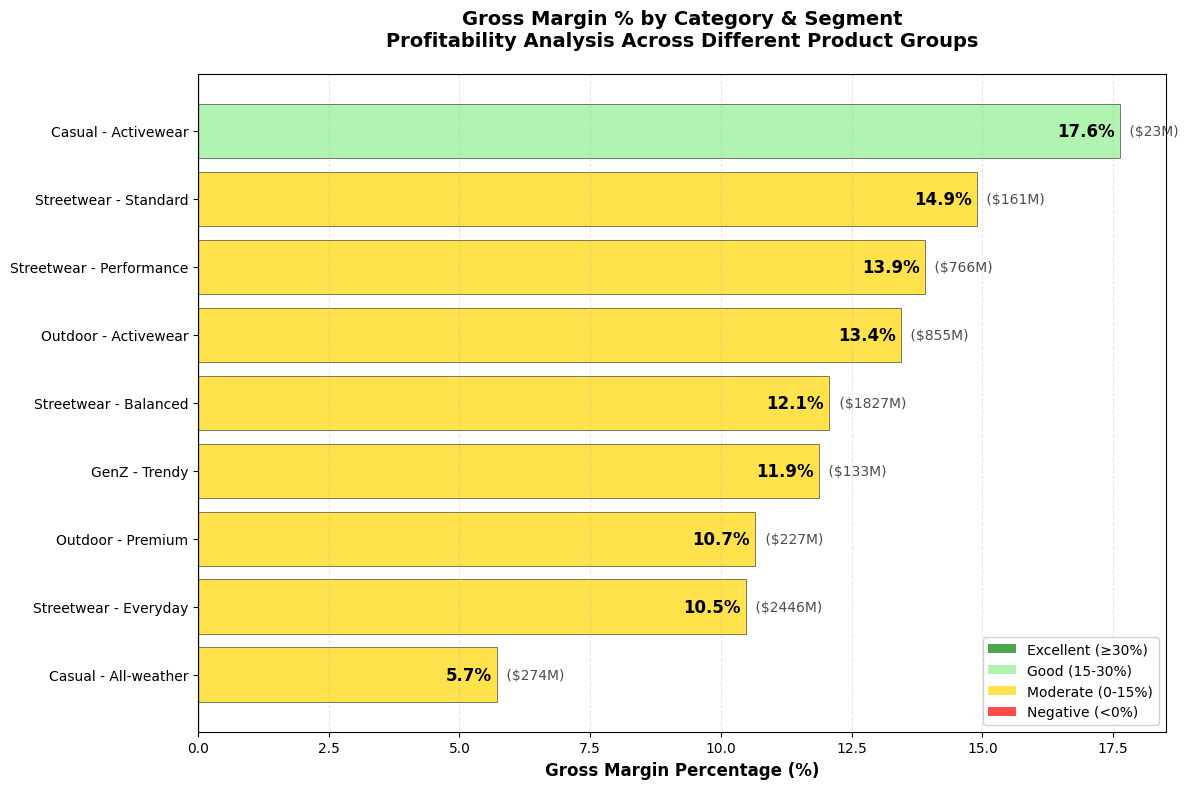


GROSS MARGIN ANALYSIS BY CATEGORY & SEGMENT
Category-Segment               Margin %     Performance     Gross Rev (M)  
--------------------------------------------------------------------------------
Casual - All-weather           5.7        % Moderate ⚠️     $273.5         
Streetwear - Everyday          10.5       % Moderate ⚠️     $2445.8        
Outdoor - Premium              10.7       % Moderate ⚠️     $227.2         
GenZ - Trendy                  11.9       % Moderate ⚠️     $133.4         
Streetwear - Balanced          12.1       % Moderate ⚠️     $1827.3        
Outdoor - Activewear           13.4       % Moderate ⚠️     $854.6         
Streetwear - Performance       13.9       % Moderate ⚠️     $766.1         
Streetwear - Standard          14.9       % Moderate ⚠️     $160.9         
Casual - Activewear            17.6       % Good ✅          $22.6          

📊 KEY INSIGHTS:
--------------------------------------------------------------------------------
🏆 BEST MARGIN: C

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


# Calculate weighted average gross margin % by category and segment
category_segment_margin = df.groupby(['category', 'segment']).agg({
    'gross_margin_pct': 'mean',
    'gross_revenue': 'sum'  # For additional context
}).reset_index()

# Create a combined label for better readability
category_segment_margin['label'] = category_segment_margin['category'] + ' - ' + category_segment_margin['segment']

# Sort by gross margin percentage for better visualization
category_segment_margin = category_segment_margin.sort_values('gross_margin_pct', ascending=True)

# Set up the plot
fig, ax = plt.subplots(figsize=(12, 8))

# Define colors based on margin performance
colors = []
for margin in category_segment_margin['gross_margin_pct']:
    if margin >= 30:
        colors.append('green')
    elif margin >= 15:
        colors.append('lightgreen')
    elif margin >= 0:
        colors.append('gold')
    else:
        colors.append('red')

# Create horizontal bars
bars = ax.barh(category_segment_margin['label'], 
               category_segment_margin['gross_margin_pct'], 
               color=colors, alpha=0.7, edgecolor='black', linewidth=0.5)

# Add vertical line at 0
ax.axvline(x=0, color='black', linewidth=1, linestyle='-', alpha=0.5)

# Add value labels at the end of each bar
for i, (bar, margin, revenue) in enumerate(zip(bars, 
                                                category_segment_margin['gross_margin_pct'],
                                                category_segment_margin['gross_revenue'] / 1e6)):
    # Position text at the end of the bar (or beginning for negative values)
    if margin >= 0:
        x_pos = margin -0.1
        ha = 'right'
    else:
        x_pos = margin + 0.1
        ha = 'left'
    
    # Add margin value
    ax.text(x_pos, bar.get_y() + bar.get_height()/2, 
            f'{margin:.1f}%', 
            ha=ha, va='center', fontsize=12, fontweight='bold')
    
    # Add revenue info in smaller text
    revenue_text = f' (${revenue:.0f}M)'
    if margin >= 0:
        ax.text(x_pos + 0.2, bar.get_y() + bar.get_height()/2, 
                revenue_text, ha='left', va='center', fontsize=10, alpha=0.7)
    else:
        ax.text(x_pos + 0.2, bar.get_y() + bar.get_height()/2, 
                revenue_text, ha='right', va='center', fontsize=10, alpha=0.7)

# Customize the chart
ax.set_xlabel('Gross Margin Percentage (%)', fontsize=12, fontweight='bold')
ax.set_title('Gross Margin % by Category & Segment\nProfitability Analysis Across Different Product Groups', 
             fontsize=14, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3, axis='x', linestyle='--')

# Add legend for margin performance
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='green', alpha=0.7, label='Excellent (≥30%)'),
    Patch(facecolor='lightgreen', alpha=0.7, label='Good (15-30%)'),
    Patch(facecolor='gold', alpha=0.7, label='Moderate (0-15%)'),
    Patch(facecolor='red', alpha=0.7, label='Negative (<0%)')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10, framealpha=0.9)

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

# Print detailed analysis
print("\n" + "="*80)
print("GROSS MARGIN ANALYSIS BY CATEGORY & SEGMENT")
print("="*80)
print(f"{'Category-Segment':<30} {'Margin %':<12} {'Performance':<15} {'Gross Rev (M)':<15}")
print("-"*80)

for _, row in category_segment_margin.iterrows():
    margin = row['gross_margin_pct']
    revenue_m = row['gross_revenue'] / 1e6
    
    if margin >= 30:
        performance = "Excellent 🌟"
    elif margin >= 15:
        performance = "Good ✅"
    elif margin >= 0:
        performance = "Moderate ⚠️"
    else:
        performance = "Negative ❌"
    
    print(f"{row['label']:<30} {margin:<11.1f}% {performance:<15} ${revenue_m:<14.1f}")

print("="*80)

# Key insights
print("\n📊 KEY INSIGHTS:")
print("-"*80)

# Best performer
best = category_segment_margin.loc[category_segment_margin['gross_margin_pct'].idxmax()]
print(f"🏆 BEST MARGIN: {best['label']} - {best['gross_margin_pct']:.1f}%")

# Worst performer
worst = category_segment_margin.loc[category_segment_margin['gross_margin_pct'].idxmin()]
print(f"📉 WORST MARGIN: {worst['label']} - {worst['gross_margin_pct']:.1f}%")

# Negative margins
negative = category_segment_margin[category_segment_margin['gross_margin_pct'] < 0]
if len(negative) > 0:
    print(f"⚠️  NEGATIVE MARGINS: {len(negative)} segments are losing money on gross margin")
    for _, row in negative.iterrows():
        print(f"   - {row['label']}: {row['gross_margin_pct']:.1f}%")

print("="*80)

## 2, Nhóm sản phẩm nào đang có tỷ lệ trả hàng cao nhất, và lý do chính khiến khách hàng trả lại là gì?

### Biểu đồ: Top 10 Sản phẩm có Tỷ lệ Trả hàng Cao nhất

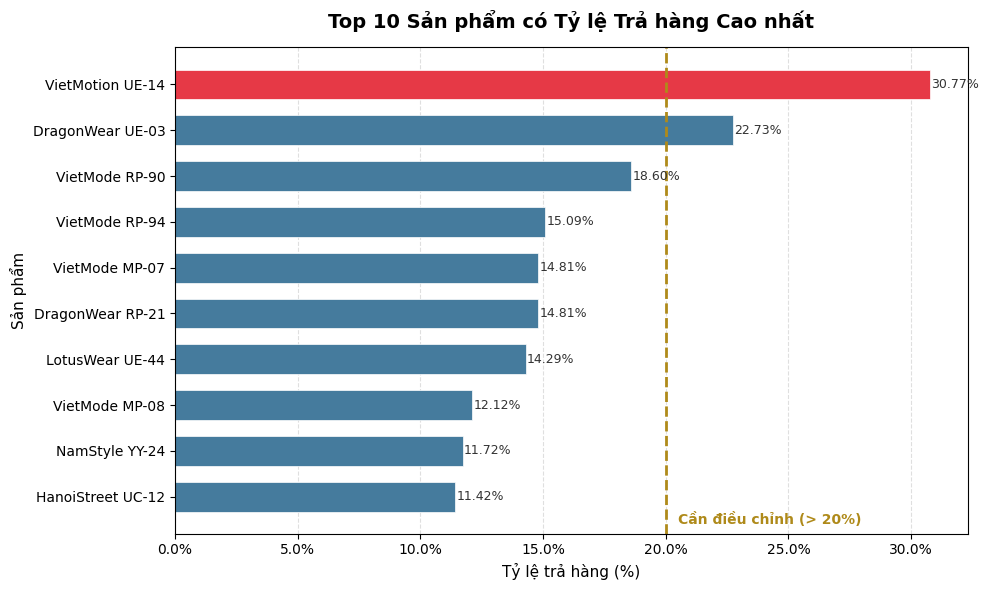

In [ ]:
# ── Thư viện ──────────────────────────────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ── 2. Lấy Top 10 theo return_rate_pct (giảm dần) ─────────────────
top10 = (
    df[["product_name", "return_rate_pct"]]
    .sort_values("return_rate_pct", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

# ── 3. Vẽ biểu đồ cột ngang ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

colors = ["#e63946" if i == 0 else "#457b9d" for i in range(10)]

bars = ax.barh(
    top10["product_name"],
    top10["return_rate_pct"],
    color=colors,
    edgecolor="white",
    linewidth=0.5,
    height=0.65,
)

# --- PHẦN THÊM MỚI: THRESHOLD LINE ---
threshold = 20
ax.axvline(
    x=threshold, 
    color="#af8a1a", 
    linestyle="--", 
    linewidth=2, 
    label=f"Threshold {threshold}%"
)

# Thêm văn bản giải thích cho đường ngưỡng
ax.text(
    threshold + 0.5, 
    9.5, 
    f"Cần điều chỉnh (> {threshold}%)", 
    color="#af8a1a", 
    fontweight="bold",
    va="center"
)
# -------------------------------------

# Sắp xếp trục Y: bar cao nhất ở trên cùng
ax.invert_yaxis()

# Nhãn giá trị trên mỗi cột
for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.05,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.2f}%",
        va="center", ha="left",
        fontsize=9, color="#333333",
    )

# Tiêu đề & nhãn trục
ax.set_title(
    "Top 10 Sản phẩm có Tỷ lệ Trả hàng Cao nhất",
    fontsize=14, fontweight="bold", pad=14,
)
ax.set_xlabel("Tỷ lệ trả hàng (%)", fontsize=11)
ax.set_ylabel("Sản phẩm", fontsize=11)

# Định dạng trục X theo %
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1f}%"))

# Lưới nền nhẹ
ax.grid(axis="x", linestyle="--", alpha=0.4)
ax.set_axisbelow(True)

plt.tight_layout()
#plt.savefig("top10_return_rate.png", dpi=150, bbox_inches="tight")
plt.show()

### Biểu đồ: Tỷ lệ Trả hàng Trung bình theo Nhóm Sản phẩm 

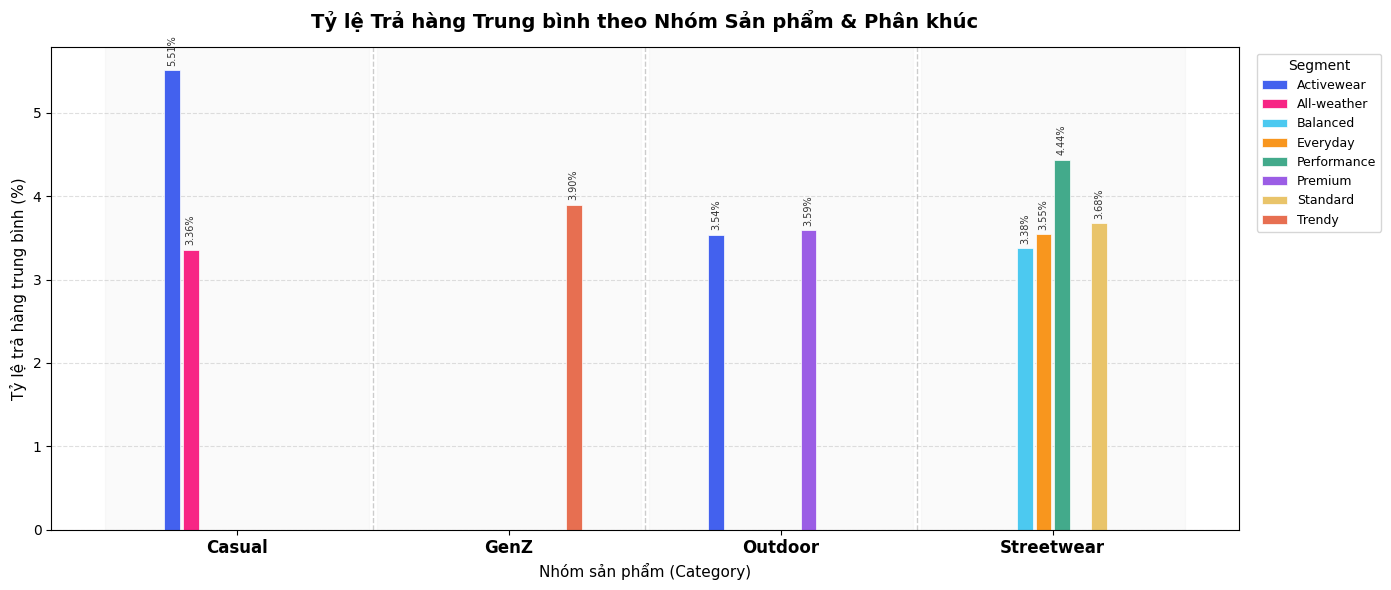

In [ ]:
# ── Thư viện ──────────────────────────────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

pivot = (
    df.groupby(["category", "segment"])["return_rate_pct"]
    .mean().round(2)
    .unstack(level="segment")
)                                      # NaN = segment không tồn tại trong category đó

categories = pivot.index.tolist()
segments   = pivot.columns.tolist()
n_cat      = len(categories)
n_seg      = len(segments)

palette = {
    "Activewear"  : "#4361ee",
    "All-weather" : "#f72585",
    "Balanced"    : "#4cc9f0",
    "Everyday"    : "#f8961e",
    "Performance" : "#43aa8b",
    "Premium"     : "#9b5de5",
    "Standard"    : "#e9c46a",
    "Trendy"      : "#e76f51",
}

# ── 2. Tính vị trí X có GAP rộng giữa các category ───────────────
bar_width   = 0.09                    # mỗi cột hẹp lại
group_gap   = 0.6                    # ★ khoảng trống bổ sung giữa các category
group_width = n_seg * bar_width       # tổng chiều rộng 1 nhóm

# Tâm của từng category
x_centers = np.array([
    i * (group_width + group_gap)
    for i in range(n_cat)
])

# ── 3. Vẽ biểu đồ ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

for i, seg in enumerate(segments):
    offset = (i - n_seg / 2 + 0.5) * bar_width
    values = pivot[seg].values          # NaN → không vẽ tự động

    bars = ax.bar(
        x_centers + offset, values,
        width=bar_width * 0.85,          # nhỏ hơn step → có khe giữa các cột
        color=palette.get(seg, "#aaa"),
        edgecolor="white", linewidth=0.5,
        label=seg,
    )

    for bar in bars:
        h = bar.get_height()
        if not np.isnan(h) and h > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                h + 0.05,
                f"{h:.2f}%",
                ha="center", va="bottom",
                fontsize=7, rotation=90, color="#333",
            )

# ── 4. ★ Đường kẻ phân cách giữa các category ────────────────────
for j in range(1, n_cat):
    sep_x = (x_centers[j - 1] + x_centers[j]) / 2
    ax.axvline(sep_x, color="#cccccc", linewidth=1, linestyle="--", zorder=0)

# ── 5. Nhãn nền mờ cho từng category (vùng tô) ───────────────────
for j, cat in enumerate(categories):
    half = (group_width + group_gap) / 2 - 0.02
    ax.axvspan(
        x_centers[j] - half, x_centers[j] + half,
        alpha=0.04,
        color="#888888",
        zorder=0,
    )

# ── 6. Định dạng trục & tiêu đề ───────────────────────────────────
ax.set_xticks(x_centers)
ax.set_xticklabels(categories, fontsize=12, fontweight="bold")
ax.set_ylabel("Tỷ lệ trả hàng trung bình (%)", fontsize=11)
ax.set_xlabel("Nhóm sản phẩm (Category)", fontsize=11)
ax.set_title(
    "Tỷ lệ Trả hàng Trung bình theo Nhóm Sản phẩm & Phân khúc",
    fontsize=14, fontweight="bold", pad=14,
)
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.set_axisbelow(True)
ax.legend(
    title="Segment",
    bbox_to_anchor=(1.01, 1),
    loc="upper left", fontsize=9,
)

plt.tight_layout()
#plt.savefig("grouped_bar_fixed.png", dpi=150, bbox_inches="tight")
plt.show()

### Biểu đồ: Tổng hợp các Lý do Trả hàng Chính (Top Return Reasons)

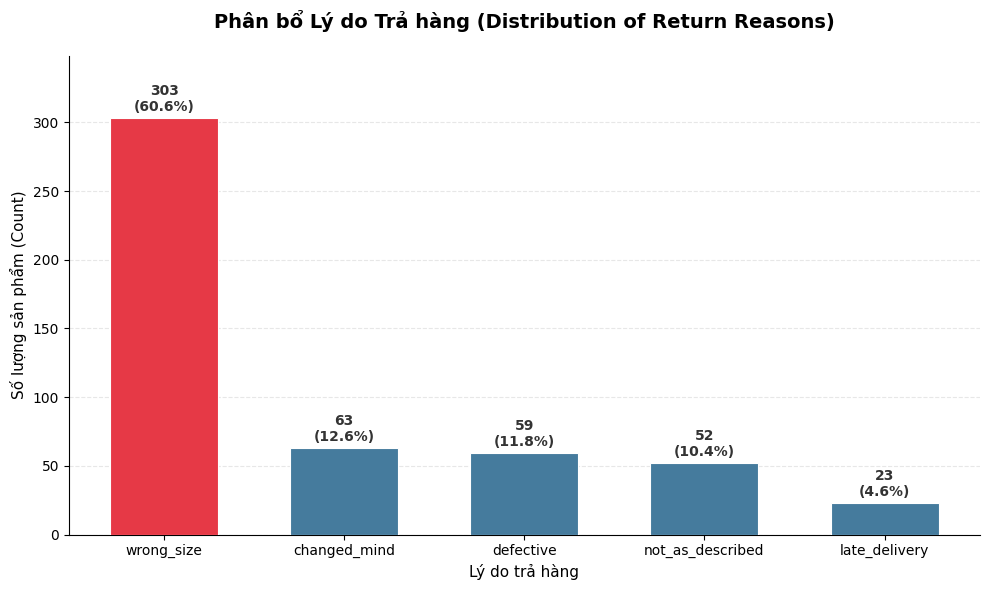

In [ ]:
# ── Thư viện ──────────────────────────────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt


reason_counts = (
    df["top_return_reason"]
    .value_counts()
    .reset_index()
)
reason_counts.columns = ["reason", "count"]
reason_counts["pct"] = (reason_counts["count"] / reason_counts["count"].sum() * 100).round(1)

# ── 2. Bảng màu đơn giản ─────────────────────────────────────────
# Sử dụng bảng màu nhẹ nhàng, tập trung vào cột cao nhất
colors = ["#e63946" if i == 0 else "#457b9d" for i in range(len(reason_counts))]

# ── 3. Vẽ biểu đồ ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(
    reason_counts["reason"],
    reason_counts["count"],
    color=colors,
    edgecolor="white",
    linewidth=0.8,
    width=0.6,
    zorder=3,
)

# ── 4. Nhãn dữ liệu (Data Labels) trên cột ────────────────────────
for bar, row in zip(bars, reason_counts.itertuples()):
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2, 
        h + (reason_counts["count"].max() * 0.01),
        f"{row.count:,}\n({row.pct}%)",
        ha="center", va="bottom",
        fontsize=10, fontweight="bold", color="#333"
    )

# ── 5. Định dạng trục và Tiêu đề ──────────────────────────────────
ax.set_title(
    "Phân bổ Lý do Trả hàng (Distribution of Return Reasons)",
    fontsize=14, fontweight="bold", pad=20,
)
ax.set_ylabel("Số lượng sản phẩm (Count)", fontsize=11)
ax.set_xlabel("Lý do trả hàng", fontsize=11)

# Làm sạch khung biểu đồ (Spines)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Lưới nền nhẹ (Grid)
ax.grid(axis="y", linestyle="--", alpha=0.3, zorder=0)
ax.set_axisbelow(True)

# Giãn trục Y để nhãn không bị chạm đỉnh
ax.set_ylim(0, reason_counts["count"].max() * 1.15)

plt.tight_layout()
#plt.savefig("top_return_reasons_clean.png", dpi=150)
plt.show()

### Biểu đồ: Lý do Trả hàng theo Danh mục (Stacked Bar Chart)

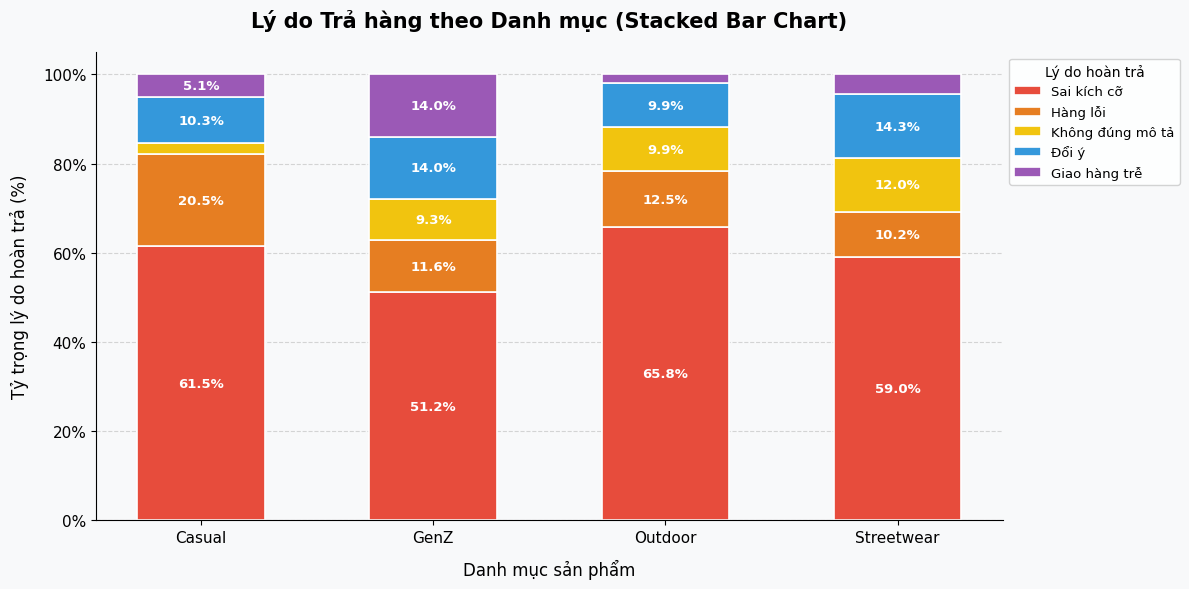

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# ── 2. Tính tỷ trọng % lý do hoàn trả theo Category ─────────────────────────
pivot = (
    df.groupby(["category", "top_return_reason"])
    .size()
    .reset_index(name="count")
)

pivot_pct = (
    pivot.pivot(index="category", columns="top_return_reason", values="count")
    .fillna(0)
)

# Chuyển sang % (tổng mỗi hàng = 100%)
pivot_pct = pivot_pct.div(pivot_pct.sum(axis=1), axis=0) * 100

# Đảm bảo thứ tự cột nhất quán
reason_order = ["wrong_size", "defective", "not_as_described", "changed_mind", "late_delivery"]
pivot_pct = pivot_pct[reason_order]

# ── 3. Màu sắc & nhãn ────────────────────────────────────────────────────────
colors = {
    "wrong_size":        "#E74C3C",   # đỏ
    "defective":         "#E67E22",   # cam
    "not_as_described":  "#F1C40F",   # vàng
    "changed_mind":      "#3498DB",   # xanh dương
    "late_delivery":     "#9B59B6",   # tím
}

labels = {
    "wrong_size":        "Sai kích cỡ",
    "defective":         "Hàng lỗi",
    "not_as_described":  "Không đúng mô tả",
    "changed_mind":      "Đổi ý",
    "late_delivery":     "Giao hàng trễ",
}

# ── 4. Vẽ biểu đồ ────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6)) # Tăng nhẹ chiều rộng để chứa Legend bên ngoài
fig.patch.set_facecolor("#F8F9FA")
ax.set_facecolor("#F8F9FA")

bottom = pd.Series([0.0] * len(pivot_pct), index=pivot_pct.index)

for reason in reason_order:
    values = pivot_pct[reason]
    bars = ax.bar(
        pivot_pct.index,
        values,
        bottom=bottom,
        color=colors[reason],
        label=labels[reason],
        edgecolor="white",
        linewidth=1.2,
        width=0.55,
    )

    # Ghi nhãn % lên từng đoạn
    for bar, val in zip(bars, values):
        if val >= 5:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_y() + bar.get_height() / 2,
                f"{val:.1f}%",
                ha="center", va="center",
                fontsize=9.5, fontweight="bold", color="white",
            )
    bottom += values

# ── 5. Định dạng trục & tiêu đề ──────────────────────────────────────────────
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_ylim(0, 105)
ax.set_xlabel("Danh mục sản phẩm", fontsize=12, labelpad=10)
ax.set_ylabel("Tỷ trọng lý do hoàn trả (%)", fontsize=12, labelpad=10)
ax.set_title(
    "Lý do Trả hàng theo Danh mục (Stacked Bar Chart)",
    fontsize=15, fontweight="bold", pad=18,
)

ax.tick_params(axis="both", labelsize=11)
ax.spines[["top", "right"]].set_visible(False)
ax.yaxis.grid(True, linestyle="--", alpha=0.5)
ax.set_axisbelow(True)

# ── 6. Chỉnh sửa Legend để không đè lên cột ──────────────────────────────────
ax.legend(
    title="Lý do hoàn trả",
    title_fontsize=10,
    fontsize=9.5,
    loc="upper left",          # Đổi điểm neo thành upper left
    bbox_to_anchor=(1, 1),     # Đẩy Legend ra khỏi trục tọa độ (x=1 là mép phải)
    framealpha=0.85,
    edgecolor="#CCCCCC",
)

plt.tight_layout() # Tự động điều chỉnh để không mất Legend khi lưu
#plt.savefig("return_reason_by_category.png", dpi=150, bbox_inches="tight")
plt.show()

### Biểu đồ: Tương quan giữa Tỷ lệ Trả hàng và Đánh giá (Average Rating)

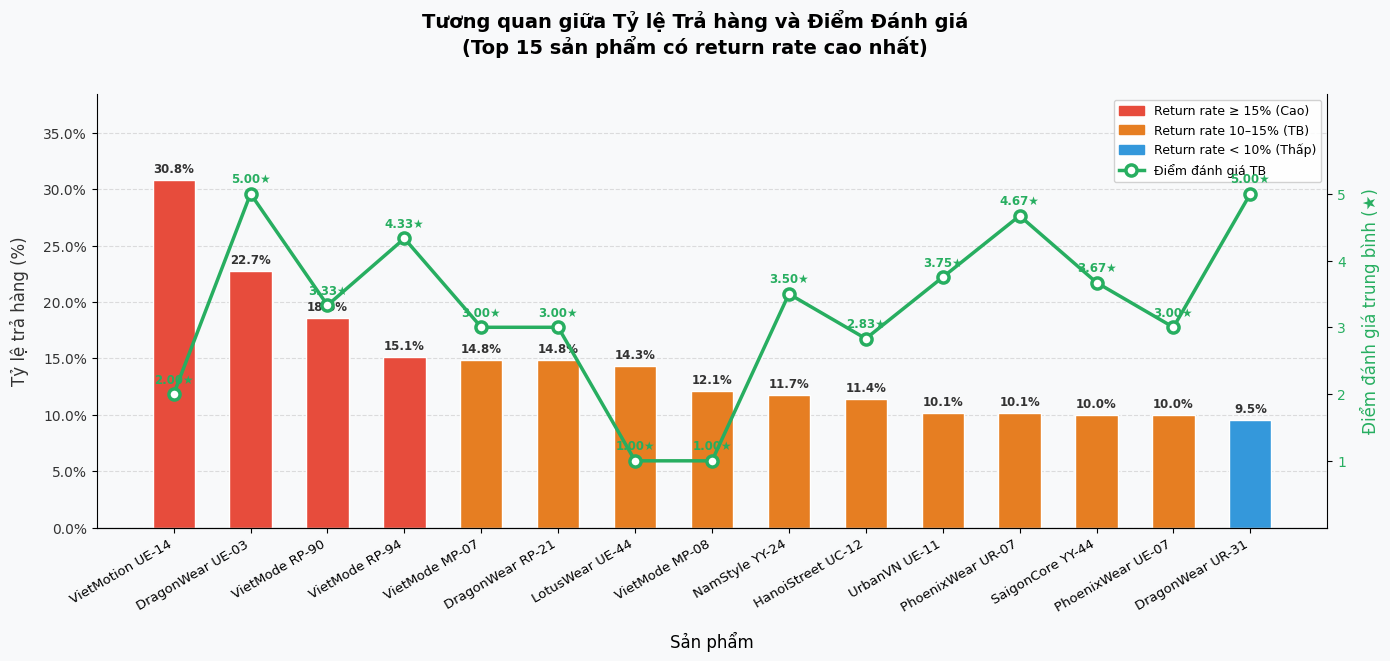

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np

top_n = 15
data = (
    df[["product_name", "return_rate_pct", "avg_rating"]]
    .sort_values("return_rate_pct", ascending=False)
    .head(top_n)
    .reset_index(drop=True)
)

# ── 2. Màu cột theo mức độ return rate ───────────────────────────────────────
def bar_color(rate):
    if rate >= 15:
        return "#E74C3C"   # đỏ — rủi ro cao
    elif rate >= 10:
        return "#E67E22"   # cam — rủi ro trung bình
    else:
        return "#3498DB"   # xanh — rủi ro thấp

colors = [bar_color(r) for r in data["return_rate_pct"]]

# ── 3. Setup figure với 2 trục Y ─────────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(14, 6.5))
fig.patch.set_facecolor("#F8F9FA")
ax1.set_facecolor("#F8F9FA")

x = np.arange(len(data))
bar_width = 0.55

# ── 4. Trục trái: Cột return_rate_pct ────────────────────────────────────────
bars = ax1.bar(
    x, data["return_rate_pct"],
    width=bar_width,
    color=colors,
    edgecolor="white",
    linewidth=1.0,
    zorder=2,
    label="Tỷ lệ trả hàng (%)",
)

# Ghi nhãn % trên đỉnh mỗi cột
for bar, val in zip(bars, data["return_rate_pct"]):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.4,
        f"{val:.1f}%",
        ha="center", va="bottom",
        fontsize=8.5, fontweight="bold", color="#333333",
    )

ax1.set_ylabel("Tỷ lệ trả hàng (%)", fontsize=12, color="#333333", labelpad=10)
ax1.yaxis.set_major_formatter(mtick.PercentFormatter())
ax1.set_ylim(0, data["return_rate_pct"].max() * 1.25)
ax1.tick_params(axis="y", labelcolor="#333333")
ax1.yaxis.grid(True, linestyle="--", alpha=0.4, zorder=0)
ax1.set_axisbelow(True)
ax1.spines[["top", "right"]].set_visible(False)

# ── 5. Trục phải: Đường avg_rating ───────────────────────────────────────────
ax2 = ax1.twinx()
ax2.set_facecolor("none")

line, = ax2.plot(
    x, data["avg_rating"],
    color="#27AE60",
    marker="o",
    markersize=8,
    linewidth=2.5,
    markerfacecolor="white",
    markeredgewidth=2.5,
    markeredgecolor="#27AE60",
    zorder=3,
    label="Điểm đánh giá TB",
)

# Ghi nhãn điểm rating trên mỗi điểm
for xi, val in zip(x, data["avg_rating"]):
    ax2.text(
        xi, val + 0.12,
        f"{val:.2f}★",
        ha="center", va="bottom",
        fontsize=8.5, color="#27AE60", fontweight="bold",
    )

ax2.set_ylabel("Điểm đánh giá trung bình (★)", fontsize=12, color="#27AE60", labelpad=10)
ax2.set_ylim(0, 6.5)
ax2.set_yticks([1, 2, 3, 4, 5])
ax2.tick_params(axis="y", labelcolor="#27AE60")
ax2.spines[["top", "left"]].set_visible(False)

# ── 6. Trục X: Nhãn sản phẩm ─────────────────────────────────────────────────
ax1.set_xticks(x)
ax1.set_xticklabels(
    data["product_name"],
    rotation=30, ha="right", fontsize=9.5,
)
ax1.set_xlabel("Sản phẩm", fontsize=12, labelpad=12)

# ── 7. Tiêu đề & Legend ──────────────────────────────────────────────────────
fig.suptitle(
    "Tương quan giữa Tỷ lệ Trả hàng và Điểm Đánh giá\n(Top 15 sản phẩm có return rate cao nhất)",
    fontsize=14, fontweight="bold", y=1.01,
)

# Ghép legend từ cả 2 trục
legend_patches = [
    plt.Rectangle((0,0),1,1, color="#E74C3C", label="Return rate ≥ 15% (Cao)"),
    plt.Rectangle((0,0),1,1, color="#E67E22", label="Return rate 10–15% (TB)"),
    plt.Rectangle((0,0),1,1, color="#3498DB", label="Return rate < 10% (Thấp)"),
    line,
]
ax1.legend(
    handles=legend_patches,
    loc="upper right",
    fontsize=9,
    framealpha=0.88,
    edgecolor="#CCCCCC",
)

plt.tight_layout()
#plt.savefig("return_rate_vs_rating.png", dpi=150, bbox_inches="tight")
plt.show()

## 3, Tình trạng tồn kho hiện tại phân bổ ra sao? Những mặt hàng nào đang gặp tình trạng hết hàng hoặc tồn kho quá mức?

### 1. Biểu đồ: Tổng quan Trạng thái Kho hàng (Inventory Status Overview)
*   **Loại biểu đồ:** Biểu đồ tròn (Pie Chart) hoặc Biểu đồ cột chồng (Stacked Bar Chart).
*   **Cột sử dụng:** `stockout_flag`, `overstock_flag`.
*   **Mô tả:** Bạn tạo một cột phái sinh (ví dụ: `Inventory_Status`) dựa trên hai cờ (flag) này để phân loại sản phẩm thành 3 nhóm: "Stockout", "Overstock" và "Healthy" (không bị cả hai).
*   **Insight:** Cho biết tỷ lệ phần trăm danh mục hàng hóa đang nằm trong vùng nguy hiểm. Ví dụ: Nếu 40% sản phẩm là `overstock_flag = true`, doanh nghiệp đang bị đọng vốn rất lớn.


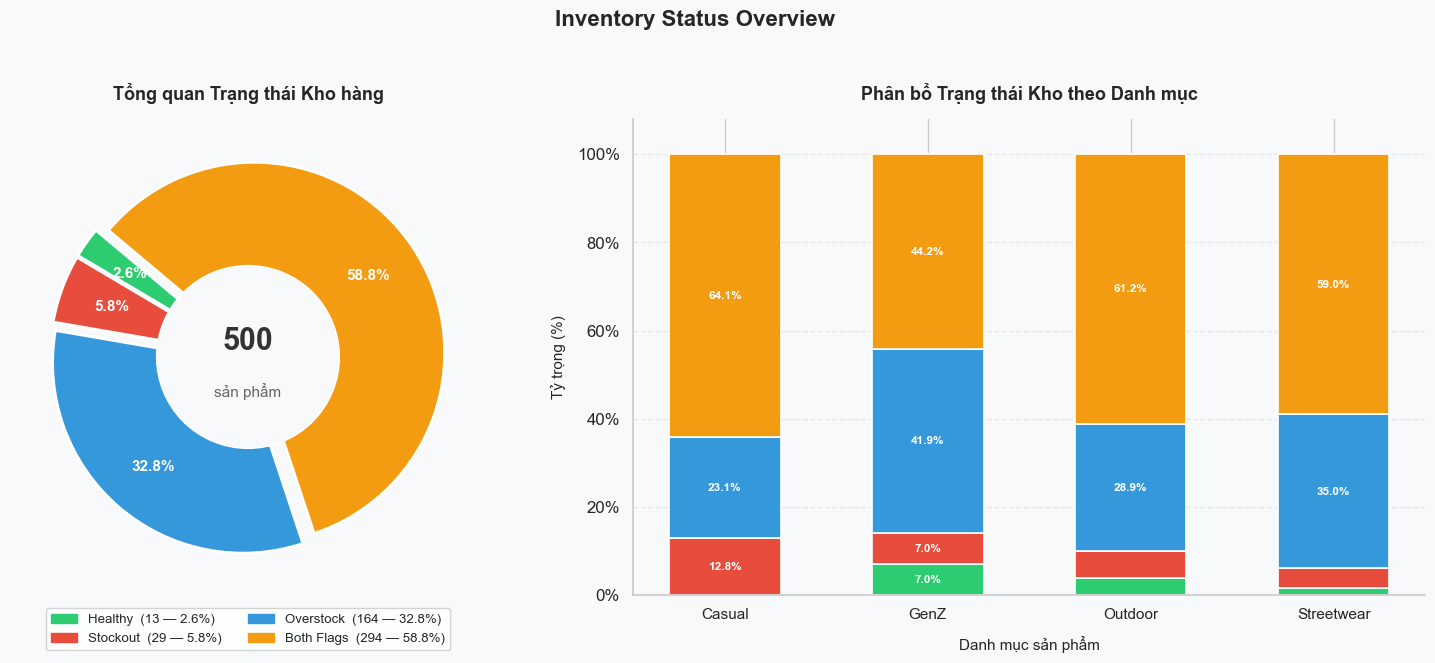

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

def classify_inventory(row):
    if row["stockout_flag"] and row["overstock_flag"]:
        return "Both Flags"   # vừa hết hàng vừa tồn dư (data inconsistency)
    elif row["stockout_flag"]:
        return "Stockout"
    elif row["overstock_flag"]:
        return "Overstock"
    else:
        return "Healthy"

df["inventory_status"] = df.apply(classify_inventory, axis=1)

# ── 2. Tổng hợp số liệu ───────────────────────────────────────────────────────
status_order  = ["Healthy", "Stockout", "Overstock", "Both Flags"]
color_map     = {
    "Healthy":    "#2ECC71",
    "Stockout":   "#E74C3C",
    "Overstock":  "#3498DB",
    "Both Flags": "#F39C12",
}

counts = df["inventory_status"].value_counts().reindex(status_order).fillna(0).astype(int)
total  = counts.sum()
pcts   = counts / total * 100

# ── 3. Setup layout: Pie (trái) + Bar by Category (phải) ─────────────────────
fig, (ax_pie, ax_bar) = plt.subplots(
    1, 2, figsize=(15, 6.5),
    gridspec_kw={"width_ratios": [1, 1.4]},
)
fig.patch.set_facecolor("#F8F9FA")
for ax in (ax_pie, ax_bar):
    ax.set_facecolor("#F8F9FA")

# ════════════════════════════════════════════════════════════════════════════
# Biểu đồ TRÁI — Donut Chart tổng quan
# ════════════════════════════════════════════════════════════════════════════
wedge_colors = [color_map[s] for s in status_order]
explode      = [0.04] * len(status_order)

wedges, texts, autotexts = ax_pie.pie(
    counts,
    labels=None,
    colors=wedge_colors,
    explode=explode,
    autopct=lambda p: f"{p:.1f}%" if p > 0 else "",
    pctdistance=0.72,
    startangle=140,
    wedgeprops={"edgecolor": "white", "linewidth": 2},
    textprops={"fontsize": 11},
)

for at in autotexts:
    at.set_fontsize(11)
    at.set_fontweight("bold")
    at.set_color("white")

# Vòng trắng giữa → Donut
centre_circle = plt.Circle((0, 0), 0.48, fc="#F8F9FA")
ax_pie.add_patch(centre_circle)

# Số tổng ở giữa
ax_pie.text(0, 0.08, f"{total:,}", ha="center", va="center",
            fontsize=22, fontweight="bold", color="#333333")
ax_pie.text(0, -0.18, "sản phẩm", ha="center", va="center",
            fontsize=11, color="#666666")

# Legend
legend_handles = [
    mpatches.Patch(color=color_map[s], label=f"{s}  ({counts[s]:,} — {pcts[s]:.1f}%)")
    for s in status_order
]
ax_pie.legend(
    handles=legend_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.13),
    ncol=2,
    fontsize=9.5,
    framealpha=0.85,
    edgecolor="#CCCCCC",
)
ax_pie.set_title("Tổng quan Trạng thái Kho hàng", fontsize=13, fontweight="bold", pad=14)

# ════════════════════════════════════════════════════════════════════════════
# Biểu đồ PHẢI — Stacked Bar theo Category
# ════════════════════════════════════════════════════════════════════════════
cat_status = (
    df.groupby(["category", "inventory_status"])
    .size()
    .reset_index(name="count")
)
cat_pivot = (
    cat_status
    .pivot(index="category", columns="inventory_status", values="count")
    .reindex(columns=status_order)
    .fillna(0)
)
cat_pct = cat_pivot.div(cat_pivot.sum(axis=1), axis=0) * 100

x      = np.arange(len(cat_pct))
bottom = np.zeros(len(cat_pct))

for status in status_order:
    vals = cat_pct[status].values
    bars = ax_bar.bar(
        x, vals,
        bottom=bottom,
        color=color_map[status],
        width=0.55,
        edgecolor="white",
        linewidth=1.2,
        label=status,
    )
    for bar, val in zip(bars, vals):
        if val >= 6:
            ax_bar.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_y() + bar.get_height() / 2,
                f"{val:.1f}%",
                ha="center", va="center",
                fontsize=8.5, fontweight="bold", color="white",
            )
    bottom += vals

ax_bar.set_xticks(x)
ax_bar.set_xticklabels(cat_pct.index, fontsize=11)
ax_bar.set_ylabel("Tỷ trọng (%)", fontsize=11, labelpad=8)
ax_bar.set_ylim(0, 108)
ax_bar.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0f}%"))
ax_bar.set_xlabel("Danh mục sản phẩm", fontsize=11, labelpad=10)
ax_bar.set_title("Phân bổ Trạng thái Kho theo Danh mục", fontsize=13, fontweight="bold", pad=14)
ax_bar.spines[["top", "right"]].set_visible(False)
ax_bar.yaxis.grid(True, linestyle="--", alpha=0.4)
ax_bar.set_axisbelow(True)

# ── 4. Tiêu đề tổng ──────────────────────────────────────────────────────────
fig.suptitle(
    "Inventory Status Overview",
    fontsize=16, fontweight="bold", y=1.02,
)

plt.tight_layout()
plt.savefig("inventory_status_overview.png", dpi=150, bbox_inches="tight")
plt.show()

### 2. Biểu đồ: Tỷ lệ Hết hàng và Tồn kho quá mức theo Danh mục (Stock Issue Rates by Category)
*   **Loại biểu đồ:** Biểu đồ cột nhóm (Grouped Bar Chart).
*   **Cột sử dụng:** `category`, `stockout_flag`, `overstock_flag`.
*   **Mô tả:** Trục X là các Category (Streetwear, Outdoor, Casual...), trục Y là số lượng (count) hoặc tỷ lệ % các sản phẩm bị Stockout hoặc Overstock trong nhóm đó.
*   **Insight:** Xác định nhóm hàng nào đang bị quản lý kho kém nhất. 
    *   **Ví dụ:** Nếu nhóm *Outdoor* có tỷ lệ `stockout_flag` cao, bạn đang bỏ lỡ cơ hội bán hàng. Nếu nhóm *Streetwear* có tỷ lệ `overstock_flag` cao, nhóm này cần các chương trình khuyến mãi để giải phóng kho.


✅ Thông tin các flags:
     category  stockout_flag  overstock_flag
0  Streetwear          False            True
1  Streetwear          False            True
2  Streetwear           True            True
3  Streetwear          False            True
4  Streetwear           True            True

✅ Tỷ lệ % theo từng danh mục:
     category  stockout_flag  overstock_flag
0      Casual      76.923077       87.179487
3  Streetwear      63.533835       93.984962
2     Outdoor      67.105263       90.131579
1        GenZ      51.162791       86.046512


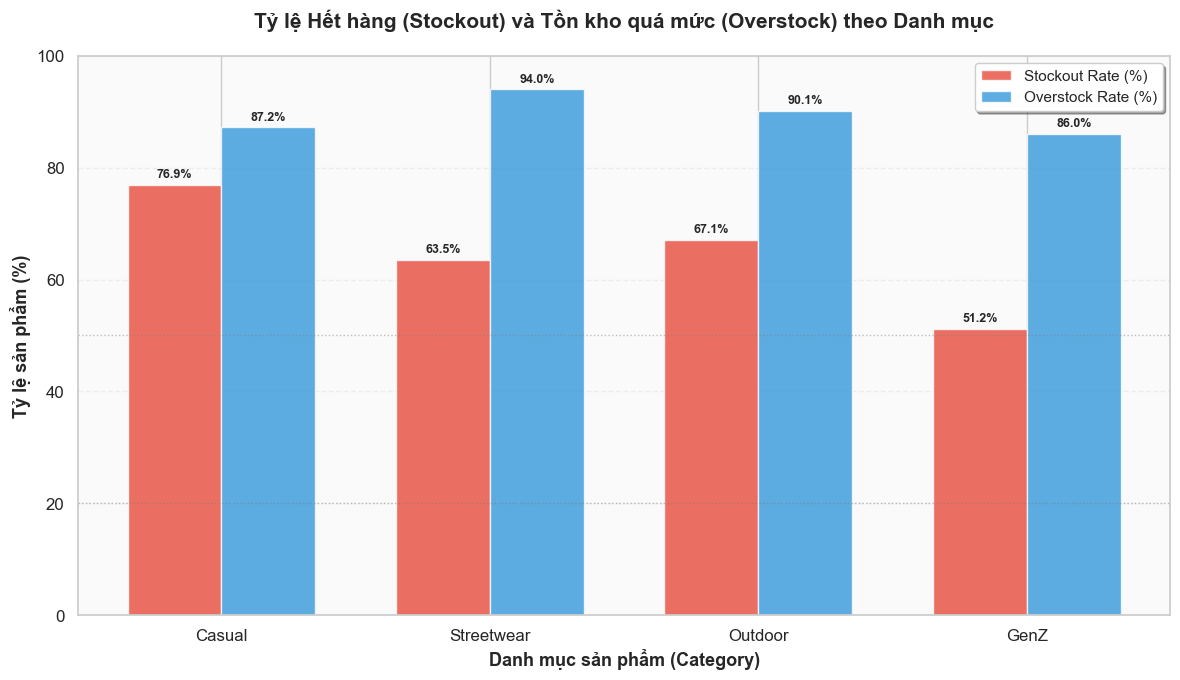

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



# Kiểm tra cấu trúc dữ liệu (nên chạy thử để debug)
print("\n✅ Thông tin các flags:")
print(df[['category', 'stockout_flag', 'overstock_flag']].head())

# ---------------------------
# 1. Tính tỷ lệ % stockout và overstock theo từng category
# ---------------------------
grouped = df.groupby('category')[['stockout_flag', 'overstock_flag']].mean() * 100
grouped = grouped.reset_index()

# Sắp xếp theo tổng tỷ lệ vấn đề cao nhất (tùy chọn)
grouped['total_issue'] = grouped['stockout_flag'] + grouped['overstock_flag']
grouped = grouped.sort_values('total_issue', ascending=False).drop('total_issue', axis=1)

print("\n✅ Tỷ lệ % theo từng danh mục:")
print(grouped)

# ---------------------------
# 2. Vẽ biểu đồ cột nhóm
# ---------------------------
x = np.arange(len(grouped['category']))  # vị trí các nhóm
width = 0.35  # độ rộng mỗi cột

fig, ax = plt.subplots(figsize=(12, 7))
bars1 = ax.bar(x - width/2, grouped['stockout_flag'], width, 
               label='Stockout Rate (%)', color='#E74C3C', alpha=0.8)
bars2 = ax.bar(x + width/2, grouped['overstock_flag'], width, 
               label='Overstock Rate (%)', color='#3498DB', alpha=0.8)

# Thêm số liệu trên đầu cột
for bar in bars1:
    height = bar.get_height()
    if height > 0:
        ax.annotate(f'{height:.1f}%',
                    xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=9, fontweight='bold')
        
for bar in bars2:
    height = bar.get_height()
    if height > 0:
        ax.annotate(f'{height:.1f}%',
                    xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

# Định dạng biểu đồ
ax.set_xlabel('Danh mục sản phẩm (Category)', fontsize=13, fontweight='bold')
ax.set_ylabel('Tỷ lệ sản phẩm (%)', fontsize=13, fontweight='bold')
ax.set_title('Tỷ lệ Hết hàng (Stockout) và Tồn kho quá mức (Overstock) theo Danh mục', 
             fontsize=15, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(grouped['category'], rotation=0, ha='center')
ax.legend(loc='upper right', fontsize=11, frameon=True, shadow=True)
ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.set_ylim(0, 100)

# Thêm đường kẻ ngang tham chiếu ở mức 20% và 50% (tùy chọn)
ax.axhline(y=20, color='gray', linestyle=':', alpha=0.5, linewidth=1)
ax.axhline(y=50, color='gray', linestyle=':', alpha=0.5, linewidth=1)

# Tùy chỉnh màu nền
ax.set_facecolor('#FAFAFA')
fig.patch.set_facecolor('white')

plt.tight_layout()
plt.savefig("stockout_overstock_by_category.png", dpi=150, bbox_inches="tight")
plt.show()

### 3. Biểu đồ: Top 10 Sản phẩm có Tồn kho cao nhất (Top 10 Overstocked Items)
*   **Loại biểu đồ:** Biểu đồ cột ngang (Horizontal Bar Chart).
*   **Cột sử dụng:** `product_name`, `stock_on_hand`. (Lọc những sản phẩm có `overstock_flag = true`).
*   **Insight:** Liệt kê đích danh những sản phẩm đang "chiếm chỗ" nhiều nhất trong kho. Đây là danh sách ưu tiên hàng đầu cho bộ phận vận hành để thực hiện các chiến dịch giảm giá (clearance sale).

✅ Kiểm tra dữ liệu:
Tổng số dòng: 500
Các cột hiện có: ['product_id', 'product_name', 'category', 'segment', 'size', 'color', 'list_price', 'cogs', 'orders_count', 'total_units_sold', 'gross_revenue', 'net_revenue', 'total_discount_amount', 'avg_selling_price', 'promo_attach_rate_pct', 'gross_margin_pct', 'total_return_events', 'total_units_returned', 'total_refund_amount', 'return_rate_pct', 'top_return_reason', 'returns_wrong_size', 'returns_defective', 'returns_not_as_described', 'returns_changed_mind', 'returns_late_delivery', 'total_reviews', 'avg_rating', 'positive_reviews', 'negative_reviews', 'stock_on_hand', 'days_of_supply', 'fill_rate', 'sell_through_rate', 'stockout_flag', 'overstock_flag', 'reorder_flag', 'latest_snapshot_date', 'product_risk_tier', 'inventory_status']

Số lượng sản phẩm overstock (overstock_flag = True/1): 458


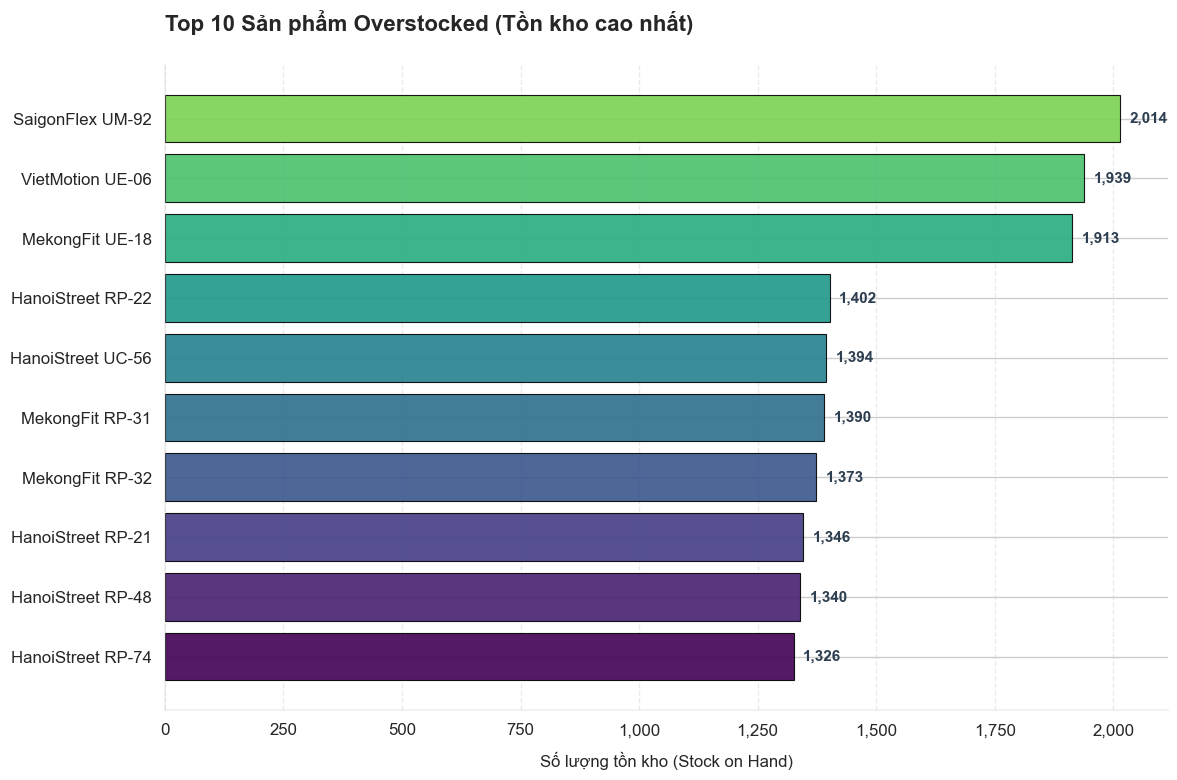

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
# ---------------------------
# Giả định: Bạn đã có dataset product_return
# Nếu cần load file, bỏ comment dòng phù hợp:
# product_return = pd.read_csv('product_return.csv')
# product_return = pd.read_excel('product_return.xlsx')
# ---------------------------

# ---------------------------
# 1. Kiểm tra cấu trúc dữ liệu
# ---------------------------
print("✅ Kiểm tra dữ liệu:")
print(f"Tổng số dòng: {len(df)}")
print(f"Các cột hiện có: {df.columns.tolist()}")
print(f"\nSố lượng sản phẩm overstock (overstock_flag = True/1): {df['overstock_flag'].sum()}")

# ---------------------------
# 2. Lọc sản phẩm overstock và lấy Top 10 theo stock_on_hand
# ---------------------------
# Lọc những sản phẩm có overstock_flag = True (hoặc = 1)
overstock_products = df[df['overstock_flag'] == True].copy()

# Kiểm tra nếu không có sản phẩm overstock
if len(overstock_products) == 0:
    print("⚠️ Không có sản phẩm nào bị overstock")
else:
    # Lấy Top 10
    top10_overstock = overstock_products.nlargest(10, 'stock_on_hand')[['product_name', 'stock_on_hand']]
    top10_overstock = top10_overstock.sort_values('stock_on_hand', ascending=True)

    # ── 3. Vẽ biểu đồ với dải màu sắc đa dạng ─────────────────────────────
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Tạo dải màu dựa trên số lượng cột (ví dụ 10 màu từ bảng màu 'viridis')
    # Bạn có thể thay 'viridis' bằng 'plasma', 'coolwarm', hoặc 'Set3'
    colors = plt.cm.viridis(np.linspace(0, 0.8, len(top10_overstock)))

    # Vẽ thanh ngang với mảng màu 'colors'
    bars = ax.barh(
        top10_overstock['product_name'], 
        top10_overstock['stock_on_hand'],
        color=colors,         # Áp dụng danh sách màu
        edgecolor='black',    # Viền đen nhẹ để tách biệt các cột
        linewidth=0.8,
        alpha=0.9
    )

    # Thêm số liệu ở đầu mỗi thanh
    max_val = top10_overstock['stock_on_hand'].max()
    for bar in bars:
        width = bar.get_width()
        ax.text(
            width + (max_val * 0.01),
            bar.get_y() + bar.get_height()/2,
            f'{int(width):,}',
            va='center', ha='left',
            fontsize=11, fontweight='bold',
            color='#2C3E50' # Màu chữ tối cho chuyên nghiệp
        )

    # Định dạng biểu đồ
    ax.set_xlabel('Số lượng tồn kho (Stock on Hand)', fontsize=12, labelpad=10)
    ax.set_title('Top 10 Sản phẩm Overstocked (Tồn kho cao nhất)', 
                 fontsize=16, fontweight='bold', pad=25, loc='left')

    # Làm sạch khung biểu đồ (loại bỏ đường viền trên và phải)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_alpha(0.3)
    ax.spines['left'].set_alpha(0.3)

    # Tùy chỉnh lưới
    ax.xaxis.grid(True, linestyle='--', alpha=0.4, zorder=0)
    ax.set_axisbelow(True)

    # Format số trục X
    ax.get_xaxis().set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

    plt.tight_layout()
    plt.savefig("top10_overstock.png", dpi=150, bbox_inches="tight")
    plt.show()

### 4. Biểu đồ: Phân bổ số lượng Tồn kho theo Nhóm (Stock Distribution Boxplot)
*   **Loại biểu đồ:** Biểu đồ hộp (Boxplot).
*   **Cột sử dụng:** `category`, `stock_on_hand`.
*   **Insight:** Giúp quan sát độ phân tán của hàng tồn kho. 
    *   Nhìn vào dải Median (trung vị) và các điểm Outliers (điểm dị biệt). Các điểm Outliers phía trên chính là những sản phẩm đang có lượng tồn kho cực lớn so với mặt bằng chung của nhóm đó, ngay cả khi chúng có thể chưa bị đánh dấu là `overstock_flag`.

C:\Users\ROG\AppData\Local\Temp\ipykernel_24948\2053691864.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


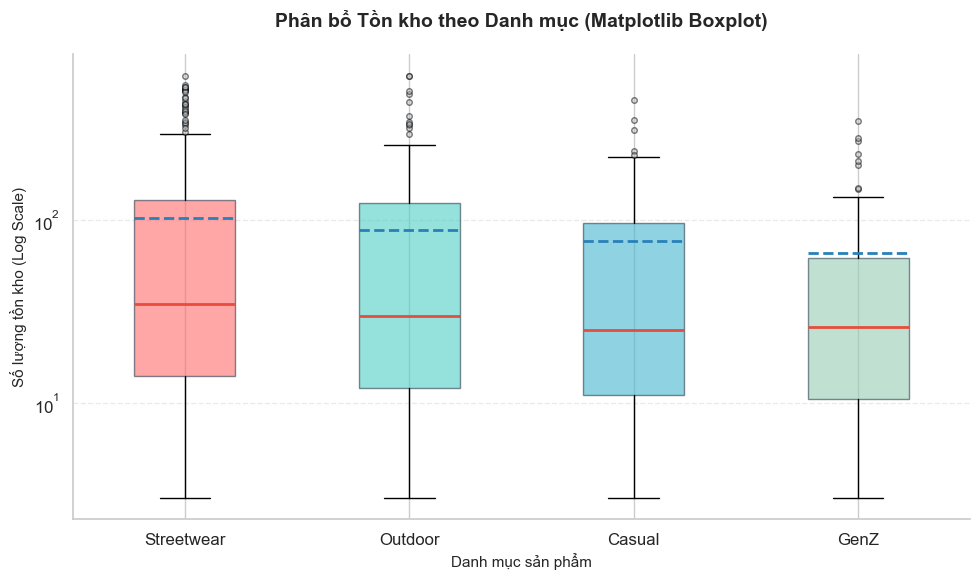

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# ── 1. Chuẩn bị dữ liệu ───────────────────────────────────────────
# Giả sử df đã được load từ trước. 
# Loại bỏ các giá trị cực đoan để biểu đồ dễ quan sát hơn.
Q1 = df['stock_on_hand'].quantile(0.25)
Q3 = df['stock_on_hand'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 3 * IQR 

df_clean = df[df['stock_on_hand'] <= upper_bound].copy()

# Chuẩn bị danh sách dữ liệu theo từng Category
categories = df_clean['category'].unique()
data_to_plot = [df_clean[df_clean['category'] == cat]['stock_on_hand'].values 
                for cat in categories]

# ── 2. Vẽ Boxplot với Matplotlib ──────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

# Cấu hình Boxplot
bp = ax.boxplot(
    data_to_plot, 
    labels=categories,
    patch_artist=True,  # Cho phép tô màu nền cho box
    showmeans=True,     # Hiển thị giá trị trung bình (Mean)
    meanline=True,      # Hiển thị Mean dạng đường kẻ thay vì marker
    meanprops={'color': '#2980b9', 'linewidth': 2, 'linestyle': '--'},
    medianprops={'color': '#e74c3c', 'linewidth': 2},
    flierprops={'marker': 'o', 'markerfacecolor': '#bdc3c7', 'markersize': 4, 'alpha': 0.5}
)

# Tô màu cho các Box để bớt đơn điệu
# Sử dụng bảng màu chuyên nghiệp
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7', '#DDA0DD']
for box, color in zip(bp['boxes'], colors[:len(categories)]):
    box.set_facecolor(color)
    box.set_alpha(0.6)
    box.set_edgecolor('#2c3e50')

# ── 3. Định dạng biểu đồ ──────────────────────────────────────────
ax.set_title('Phân bổ Tồn kho theo Danh mục (Matplotlib Boxplot)', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Danh mục sản phẩm', fontsize=11)
ax.set_ylabel('Số lượng tồn kho (Log Scale)', fontsize=11)

# Sử dụng Log Scale nếu dữ liệu có sự chênh lệch quá lớn giữa các nhóm
ax.set_yscale('log') 

# Thêm lưới nền ngang
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

# Loại bỏ đường viền thừa
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("boxplot_stock_on_hand.png", dpi=150, bbox_inches="tight")
plt.show()

### 5. Biểu đồ: Tương quan giữa Tồn kho và Số ngày cung ứng (Stock vs. Days of Supply)
*   **Loại biểu đồ:** Biểu đồ phân tán (Scatter Plot).
*   **Trục X:** `stock_on_hand`.
*   **Trục Y:** `days_of_supply`.
*   **Màu sắc (Hue):** `stockout_flag`.
*   **Insight:** 
    *   Giúp nhận diện các sản phẩm "nguy hiểm ngầm": Những sản phẩm có `stock_on_hand` cao nhưng `days_of_supply` thấp (do tốc độ bán quá nhanh), dẫn đến việc dù hiện tại có hàng nhưng vẫn bị đánh dấu `stockout_flag = true` (dự báo sẽ hết hàng cực nhanh).
    *   Xác định các mặt hàng "chết": `stock_on_hand` cao và `days_of_supply` cũng cực cao (hàng nghìn ngày), đây là những mặt hàng gần như không bán được.

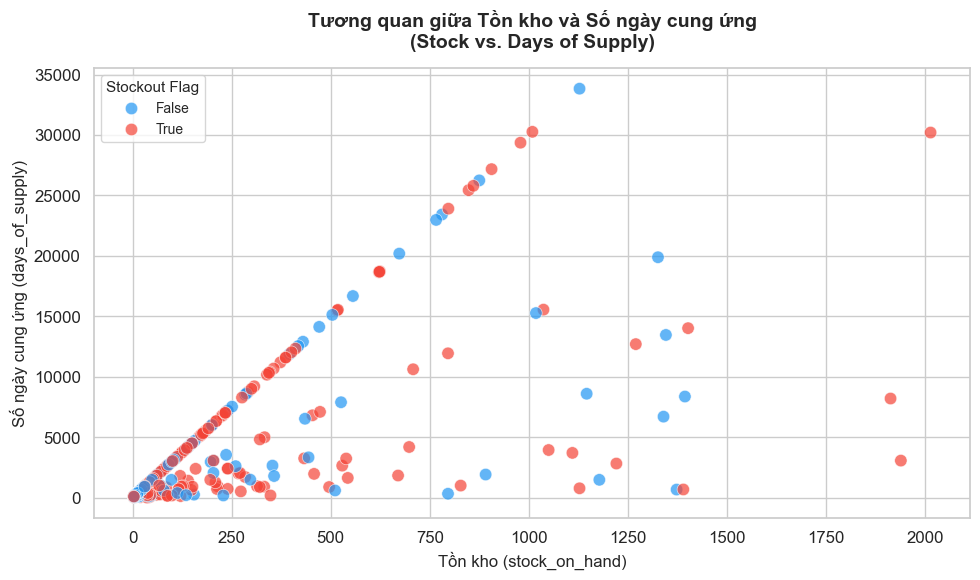

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cấu hình style
sns.set_theme(style="whitegrid", font_scale=1.1)

fig, ax = plt.subplots(figsize=(10, 6))

# Vẽ Scatter Plot
scatter = sns.scatterplot(
    data=df,
    x="stock_on_hand",
    y="days_of_supply",
    hue="stockout_flag",
    palette={0: "#2196F3", 1: "#F44336"},  # 0: Không hết hàng, 1: Hết hàng
    alpha=0.7,
    s=80,
    edgecolor="white",
    linewidth=0.5,
    ax=ax
)

# Tiêu đề và nhãn trục
ax.set_title(
    "Tương quan giữa Tồn kho và Số ngày cung ứng\n(Stock vs. Days of Supply)",
    fontsize=14, fontweight="bold", pad=15
)
ax.set_xlabel("Tồn kho (stock_on_hand)", fontsize=12)
ax.set_ylabel("Số ngày cung ứng (days_of_supply)", fontsize=12)

# Tùy chỉnh legend
handles, labels = ax.get_legend_handles_labels()
label_map = {"0": "Không hết hàng (No Stockout)", "1": "Hết hàng (Stockout)"}
new_labels = [label_map.get(l, l) for l in labels]
ax.legend(handles, new_labels, title="Stockout Flag", title_fontsize=11, fontsize=10)

plt.tight_layout()
plt.savefig("scatter_stock_days.png", dpi=150, bbox_inches="tight")
plt.show()